# Week 2: Tackle Overfitting with Data Augmentation

## Complete Practical Reference Guide

This notebook provides hands-on implementations of all concepts covered in Week 2:
- Understanding overfitting
- Image augmentation fundamentals
- Implementing augmentation with Keras Layers API
- Demonstrating overfitting and its solution
- Understanding when augmentation fails

**Prerequisites:**
- TensorFlow 2.x
- Basic understanding of CNNs from Week 1

---
## Setup and Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

2025-10-07 12:38:10.582240: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-07 12:38:10.679889: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 12:38:12.152899: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.20.0


---
## Topic 1 & 2: Understanding Overfitting

### The Shoe Analogy

**Overfitting**: When a model is very good at recognizing training data but fails on new, unseen data.

**Analogy**: If you've only seen hiking boots, you might not recognize high heels as shoes.

**In CNNs**: 
- Model memorizes specific patterns in training data
- Fails to generalize to variations it hasn't seen
- Example: All training cats sitting upright → model can't recognize lying down cats

### Visualizing Overfitting

Let's create a simple example to demonstrate overfitting:

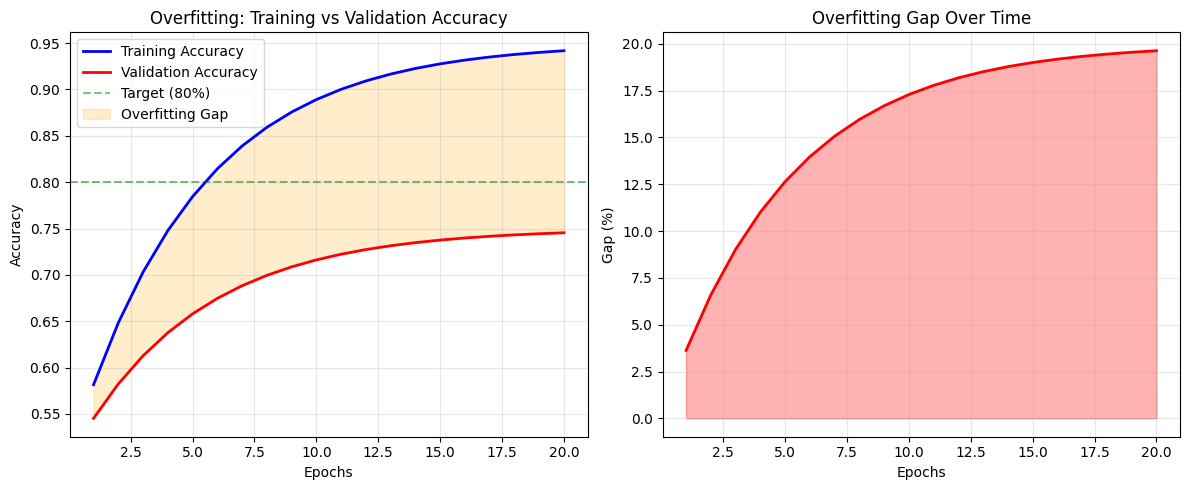

Final Training Accuracy: 94.2%
Final Validation Accuracy: 74.5%
Overfitting Gap: 19.6%


In [3]:
def plot_overfitting_example():
    """Visualize the concept of overfitting"""
    epochs = np.arange(1, 21)
    
    # Simulated training and validation accuracy
    train_acc = 0.5 + 0.45 * (1 - np.exp(-epochs/5))  # Approaches 95%
    val_acc = 0.5 + 0.25 * (1 - np.exp(-epochs/5))    # Plateaus at 75%
    
    plt.figure(figsize=(12, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    plt.axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='Target (80%)')
    plt.fill_between(epochs, train_acc, val_acc, alpha=0.2, color='orange', label='Overfitting Gap')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Overfitting: Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Gap visualization
    plt.subplot(1, 2, 2)
    gap = train_acc - val_acc
    plt.plot(epochs, gap * 100, 'r-', linewidth=2)
    plt.fill_between(epochs, 0, gap * 100, alpha=0.3, color='red')
    plt.xlabel('Epochs')
    plt.ylabel('Gap (%)')
    plt.title('Overfitting Gap Over Time')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Final Training Accuracy: {train_acc[-1]:.1%}")
    print(f"Final Validation Accuracy: {val_acc[-1]:.1%}")
    print(f"Overfitting Gap: {gap[-1]:.1%}")

plot_overfitting_example()

---
## Topic 3 & 4: Image Augmentation Fundamentals

### What is Image Augmentation?

**Definition**: Creating variations of existing images through transformations applied during training.

**Key Benefits**:
1. Effectively increases dataset size
2. Improves model generalization
3. Prevents overfitting
4. No disk storage required (in-memory)

**Important**: Augmentation happens in-memory, original images remain unchanged!

### Creating an Augmentation Pipeline

In [4]:
def create_augmentation_model(input_shape=(150, 150, 3)):
    """
    Creates a Sequential model with augmentation layers.
    
    Args:
        input_shape: Shape of input images (height, width, channels)
    
    Returns:
        tf.keras.Sequential: Augmentation model
    """
    augmentation_model = tf.keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Horizontal flip - creates mirror images
        layers.RandomFlip("horizontal"),
        
        # Rotation - up to ±72 degrees (0.2 * 2π)
        layers.RandomRotation(0.2, fill_mode="nearest"),
        
        # Translation - shift up to 20% in each direction
        layers.RandomTranslation(0.2, 0.2, fill_mode="nearest"),
        
        # Zoom - up to 20% zoom in/out
        layers.RandomZoom(0.2, fill_mode="nearest"),
        
        # Optional: Add more augmentations
        # layers.RandomContrast(0.2),
        # layers.RandomBrightness(0.2),
    ], name='data_augmentation')
    
    return augmentation_model

# Create the augmentation model
data_augmentation = create_augmentation_model()
print("Augmentation Model Summary:")
data_augmentation.summary()

Augmentation Model Summary:


2025-10-07 12:38:16.747914: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 150, 150, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 150, 150, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Understanding Each Augmentation Layer

In [5]:
def explain_augmentation_parameters():
    """
    Print detailed explanations of augmentation parameters
    """
    explanations = {
        "RandomFlip('horizontal')": {
            "Purpose": "Creates mirror images",
            "Use Case": "Objects that look similar when flipped (cats, dogs)",
            "Avoid For": "Text, signs, or orientation-specific objects"
        },
        "RandomRotation(0.2)": {
            "Purpose": "Rotates images up to ±72 degrees (0.2 × 2π)",
            "Use Case": "Objects that can appear at different angles",
            "Common Values": "0.1 (±36°), 0.2 (±72°), 0.5 (±180°)"
        },
        "RandomTranslation(0.2, 0.2)": {
            "Purpose": "Shifts images up to 20% in each direction",
            "Use Case": "Objects not always centered in frame",
            "Parameters": "(height_factor, width_factor)"
        },
        "RandomZoom(0.2)": {
            "Purpose": "Zooms in/out by up to 20%",
            "Use Case": "Objects at different distances/scales",
            "Effect": "Simulates different camera distances"
        },
        "fill_mode='nearest'": {
            "Purpose": "Fills empty pixels after transformations",
            "Method": "Uses neighboring pixel values",
            "Alternatives": "'reflect', 'constant', 'wrap'"
        }
    }
    
    for layer, details in explanations.items():
        print(f"\n{'='*60}")
        print(f"🔧 {layer}")
        print(f"{'='*60}")
        for key, value in details.items():
            print(f"  {key:15s}: {value}")

explain_augmentation_parameters()


🔧 RandomFlip('horizontal')
  Purpose        : Creates mirror images
  Use Case       : Objects that look similar when flipped (cats, dogs)
  Avoid For      : Text, signs, or orientation-specific objects

🔧 RandomRotation(0.2)
  Purpose        : Rotates images up to ±72 degrees (0.2 × 2π)
  Use Case       : Objects that can appear at different angles
  Common Values  : 0.1 (±36°), 0.2 (±72°), 0.5 (±180°)

🔧 RandomTranslation(0.2, 0.2)
  Purpose        : Shifts images up to 20% in each direction
  Use Case       : Objects not always centered in frame
  Parameters     : (height_factor, width_factor)

🔧 RandomZoom(0.2)
  Purpose        : Zooms in/out by up to 20%
  Use Case       : Objects at different distances/scales
  Effect         : Simulates different camera distances

🔧 fill_mode='nearest'
  Purpose        : Fills empty pixels after transformations
  Method         : Uses neighboring pixel values
  Alternatives   : 'reflect', 'constant', 'wrap'


### Visualizing Augmentation Effects

Let's create a sample image and see how augmentation transforms it:

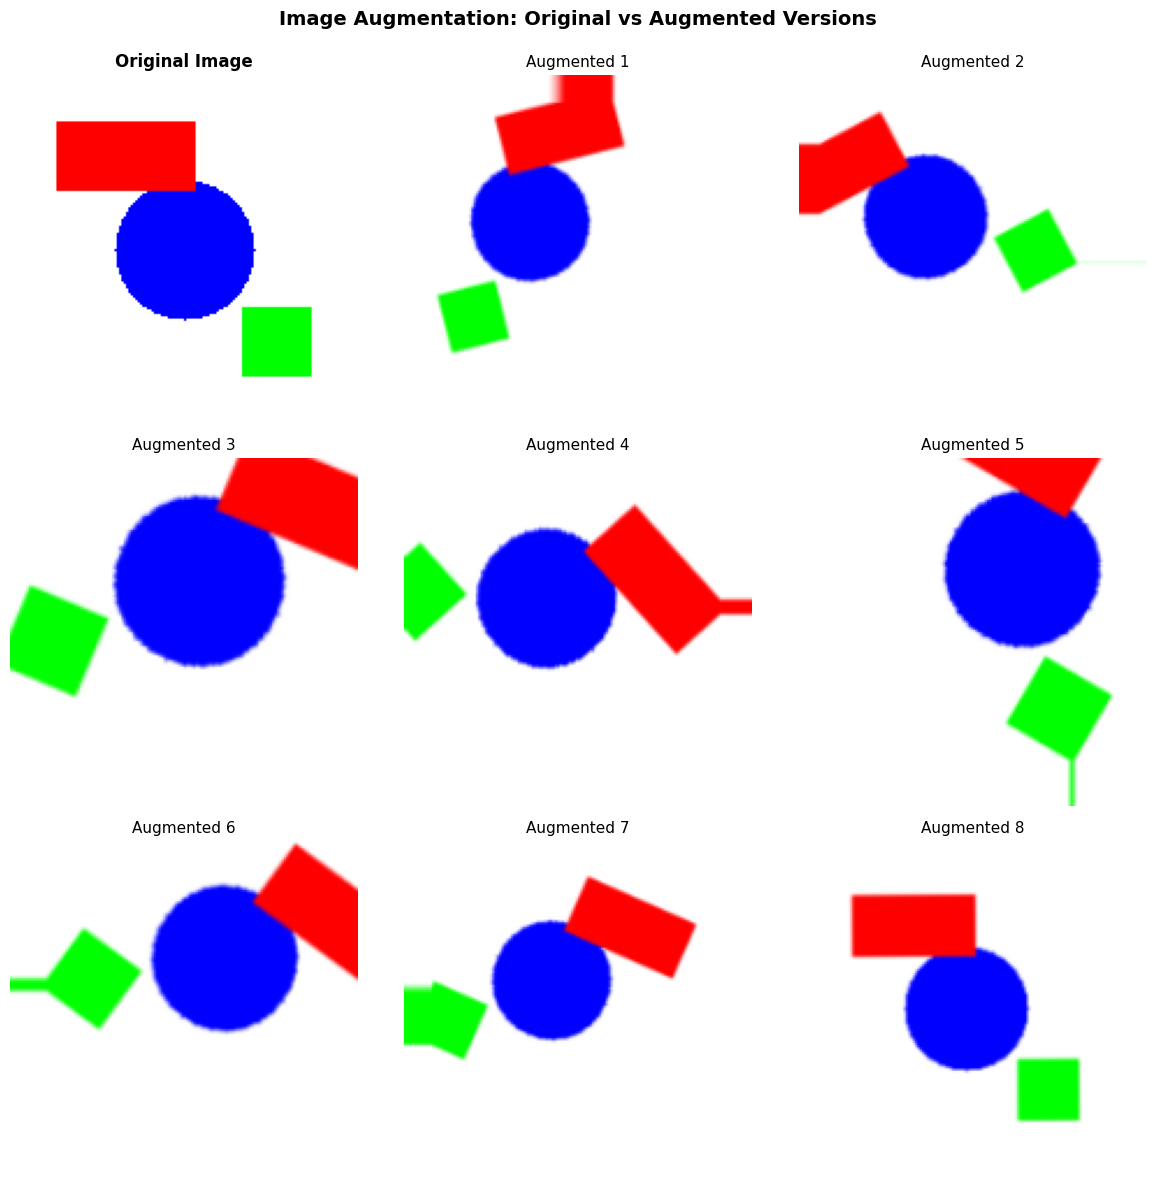

In [6]:
def create_sample_image(size=(150, 150)):
    """
    Create a simple sample image with geometric shapes
    """
    img = np.ones((*size, 3), dtype=np.float32) * 255
    
    # Add some colored shapes
    # Blue circle
    center = (size[0]//2, size[1]//2)
    radius = 30
    y, x = np.ogrid[:size[0], :size[1]]
    mask = (x - center[1])**2 + (y - center[0])**2 <= radius**2
    img[mask] = [0, 0, 255]
    
    # Red rectangle
    img[20:50, 20:80] = [255, 0, 0]
    
    # Green triangle (simplified)
    img[100:130, 100:130] = [0, 255, 0]
    
    return img

def visualize_augmentations(augmentation_model, num_augmentations=8):
    """
    Visualize multiple augmented versions of an image
    """
    # Create sample image
    sample_image = create_sample_image()
    
    # Create figure
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    
    # Original image
    axes[0].imshow(sample_image.astype('uint8'))
    axes[0].set_title('Original Image', fontweight='bold', fontsize=12)
    axes[0].axis('off')
    
    # Augmented versions
    for i in range(1, 9):
        # Apply augmentation
        augmented = augmentation_model(tf.expand_dims(sample_image, 0), training=True)
        augmented = tf.squeeze(augmented).numpy()
        
        axes[i].imshow(augmented.astype('uint8'))
        axes[i].set_title(f'Augmented {i}', fontsize=11)
        axes[i].axis('off')
    
    plt.suptitle('Image Augmentation: Original vs Augmented Versions', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Visualize augmentations
visualize_augmentations(data_augmentation)

---
## Topic 5: Complete Model Implementation

### Building a CNN with Augmentation

In [7]:
def create_cnn_with_augmentation(input_shape=(150, 150, 3), num_classes=1):
    """
    Creates a complete CNN model with data augmentation.
    
    Args:
        input_shape: Shape of input images
        num_classes: Number of output classes (1 for binary, >1 for multiclass)
    
    Returns:
        Compiled Keras model
    """
    # Get augmentation layers
    augmentation_layers = create_augmentation_model(input_shape)
    
    # Build complete model
    model = keras.Sequential([
        # Input
        layers.Input(shape=input_shape),
        
        # Data Augmentation (only active during training)
        augmentation_layers,
        
        # Rescaling (always active)
        layers.Rescaling(1./255),
        
        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu', name='conv1'),
        layers.MaxPooling2D((2, 2), name='pool1'),
        
        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),
        
        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu', name='conv3'),
        layers.MaxPooling2D((2, 2), name='pool3'),
        
        # Optional: Additional conv block for larger images
        layers.Conv2D(128, (3, 3), activation='relu', name='conv4'),
        layers.MaxPooling2D((2, 2), name='pool4'),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu', name='dense1'),
        layers.Dropout(0.5),  # Optional: helps prevent overfitting
        
        # Output layer
        layers.Dense(
            num_classes,
            activation='sigmoid' if num_classes == 1 else 'softmax',
            name='output'
        )
    ], name='cnn_with_augmentation')
    
    # Compile model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy' if num_classes == 1 else 'sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create model
model = create_cnn_with_augmentation()
print("\nModel Architecture:")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal Parameters: {total_params:,}")


Model Architecture:


Model: "cnn_with_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 3,453,121


### Model Architecture Visualization

In [8]:
%pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [8]:
def visualize_model_architecture(model):
    """
    Create a visual representation of the model architecture
    """
    # Try to use plot_model if graphviz is available
    try:
        keras.utils.plot_model(
            model,
            to_file='model_architecture.png',
            show_shapes=True,
            show_layer_names=True,
            rankdir='TB',
            expand_nested=True,
            dpi=96
        )
        print("✓ Model architecture saved to 'model_architecture.png'")
    except:
        print("⚠ Could not generate visual diagram (graphviz not installed)")
        print("Install with: pip install pydot graphviz")
    
    # Print layer-by-layer breakdown
    print("\nLayer-by-Layer Breakdown:")
    print("="*70)
    
    for i, layer in enumerate(model.layers):
        if hasattr(layer, 'output_shape'):
            output_shape = layer.output_shape
        else:
            output_shape = "N/A"
        
        params = layer.count_params()
        print(f"{i+1:2d}. {layer.name:25s} {str(output_shape):30s} {params:>10,} params")

visualize_model_architecture(model)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
✓ Model architecture saved to 'model_architecture.png'

Layer-by-Layer Breakdown:
 1. data_augmentation         (None, 150, 150, 3)                     0 params
 2. rescaling                 N/A                                     0 params
 3. conv1                     N/A                                   896 params
 4. pool1                     N/A                                     0 params
 5. conv2                     N/A                                18,496 params
 6. pool2                     N/A                                     0 params
 7. conv3                     N/A                                73,856 params
 8. pool3                     N/A                                     0 params
 9. conv4                     N/A                               147,584 params
10. pool4                     N/A                                     0 params
11. flatten      

---
## Topic 6: Training with and without Augmentation

### Simulating Training Results

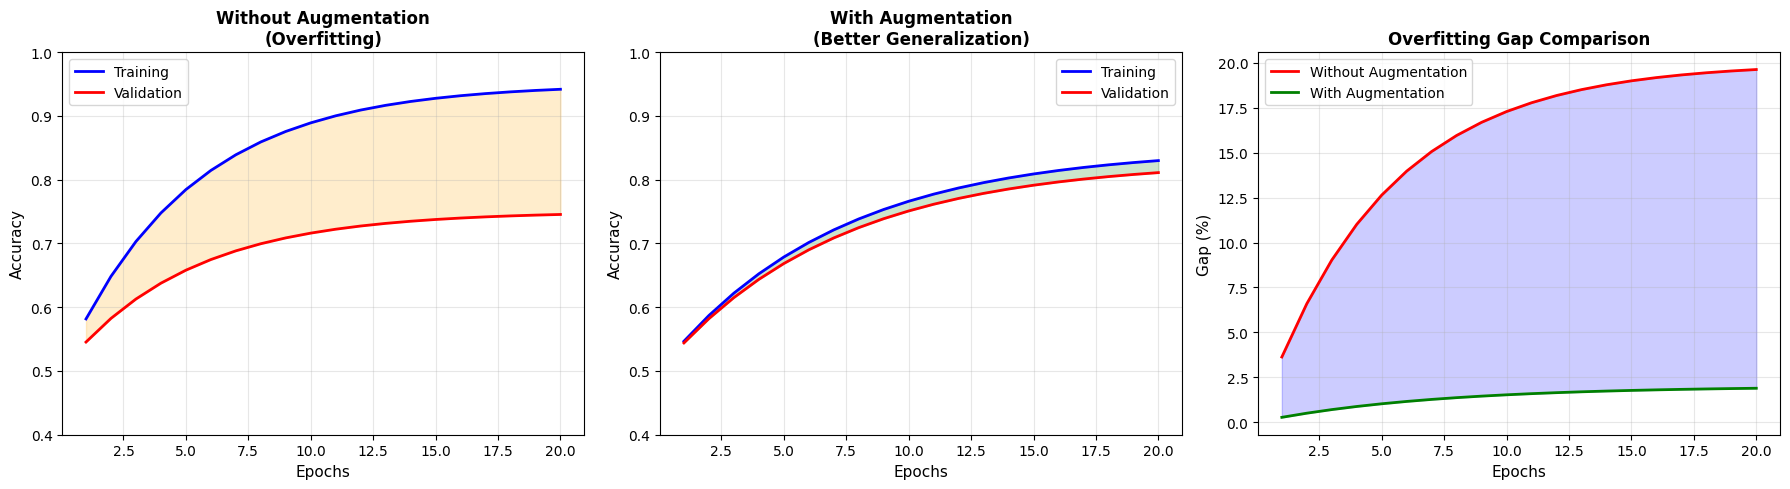


FINAL RESULTS COMPARISON (Epoch 20)

Without Augmentation:
  Training Accuracy:   94.2%
  Validation Accuracy: 74.5%
  Gap:                 19.6%

With Augmentation:
  Training Accuracy:   83.0%
  Validation Accuracy: 81.1%
  Gap:                 1.9%

✓ Gap Reduction:       17.7%


In [9]:
def simulate_training_comparison():
    """
    Simulate and compare training with and without augmentation
    """
    epochs = np.arange(1, 21)
    
    # Without augmentation - overfitting
    train_acc_no_aug = 0.5 + 0.45 * (1 - np.exp(-epochs/5))
    val_acc_no_aug = 0.5 + 0.25 * (1 - np.exp(-epochs/5))
    
    # With augmentation - better generalization
    train_acc_with_aug = 0.5 + 0.35 * (1 - np.exp(-epochs/7))
    val_acc_with_aug = 0.5 + 0.33 * (1 - np.exp(-epochs/7))
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Without Augmentation
    axes[0].plot(epochs, train_acc_no_aug, 'b-', linewidth=2, label='Training')
    axes[0].plot(epochs, val_acc_no_aug, 'r-', linewidth=2, label='Validation')
    axes[0].fill_between(epochs, train_acc_no_aug, val_acc_no_aug, alpha=0.2, color='orange')
    axes[0].set_xlabel('Epochs', fontsize=11)
    axes[0].set_ylabel('Accuracy', fontsize=11)
    axes[0].set_title('Without Augmentation\n(Overfitting)', fontweight='bold', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0.4, 1.0])
    
    # Plot 2: With Augmentation
    axes[1].plot(epochs, train_acc_with_aug, 'b-', linewidth=2, label='Training')
    axes[1].plot(epochs, val_acc_with_aug, 'r-', linewidth=2, label='Validation')
    axes[1].fill_between(epochs, train_acc_with_aug, val_acc_with_aug, alpha=0.2, color='green')
    axes[1].set_xlabel('Epochs', fontsize=11)
    axes[1].set_ylabel('Accuracy', fontsize=11)
    axes[1].set_title('With Augmentation\n(Better Generalization)', fontweight='bold', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.4, 1.0])
    
    # Plot 3: Gap Comparison
    gap_no_aug = (train_acc_no_aug - val_acc_no_aug) * 100
    gap_with_aug = (train_acc_with_aug - val_acc_with_aug) * 100
    
    axes[2].plot(epochs, gap_no_aug, 'r-', linewidth=2, label='Without Augmentation')
    axes[2].plot(epochs, gap_with_aug, 'g-', linewidth=2, label='With Augmentation')
    axes[2].fill_between(epochs, gap_no_aug, gap_with_aug, alpha=0.2, color='blue')
    axes[2].set_xlabel('Epochs', fontsize=11)
    axes[2].set_ylabel('Gap (%)', fontsize=11)
    axes[2].set_title('Overfitting Gap Comparison', fontweight='bold', fontsize=12)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final statistics
    print("\n" + "="*60)
    print("FINAL RESULTS COMPARISON (Epoch 20)")
    print("="*60)
    print(f"\nWithout Augmentation:")
    print(f"  Training Accuracy:   {train_acc_no_aug[-1]:.1%}")
    print(f"  Validation Accuracy: {val_acc_no_aug[-1]:.1%}")
    print(f"  Gap:                 {gap_no_aug[-1]:.1f}%")
    print(f"\nWith Augmentation:")
    print(f"  Training Accuracy:   {train_acc_with_aug[-1]:.1%}")
    print(f"  Validation Accuracy: {val_acc_with_aug[-1]:.1%}")
    print(f"  Gap:                 {gap_with_aug[-1]:.1f}%")
    print(f"\n✓ Gap Reduction:       {gap_no_aug[-1] - gap_with_aug[-1]:.1f}%")

simulate_training_comparison()

### Creating Early Stopping Callback

In [10]:
class EarlyStoppingCallback(keras.callbacks.Callback):
    """
    Custom callback to stop training when both training and validation
    accuracy reach specified thresholds.
    """
    
    def __init__(self, train_threshold=0.80, val_threshold=0.80):
        super().__init__()
        self.train_threshold = train_threshold
        self.val_threshold = val_threshold
    
    def on_epoch_end(self, epoch, logs=None):
        """
        Called at the end of each epoch.
        
        Args:
            epoch: Current epoch number
            logs: Dictionary containing metrics
        """
        if logs is None:
            return
        
        train_acc = logs.get('accuracy', 0)
        val_acc = logs.get('val_accuracy', 0)
        
        if train_acc >= self.train_threshold and val_acc >= self.val_threshold:
            print(f"\n✓ Reached {self.train_threshold:.0%} train accuracy and "
                  f"{self.val_threshold:.0%} validation accuracy!")
            print("  Stopping training...")
            self.model.stop_training = True

# Example usage
early_stopping = EarlyStoppingCallback(train_threshold=0.80, val_threshold=0.80)
print("✓ EarlyStoppingCallback created")
print(f"  Will stop when: train_acc >= 80% AND val_acc >= 80%")

✓ EarlyStoppingCallback created
  Will stop when: train_acc >= 80% AND val_acc >= 80%


---
## Topic 7: When Augmentation Fails - Horses vs Humans Case

### Understanding Augmentation Limitations

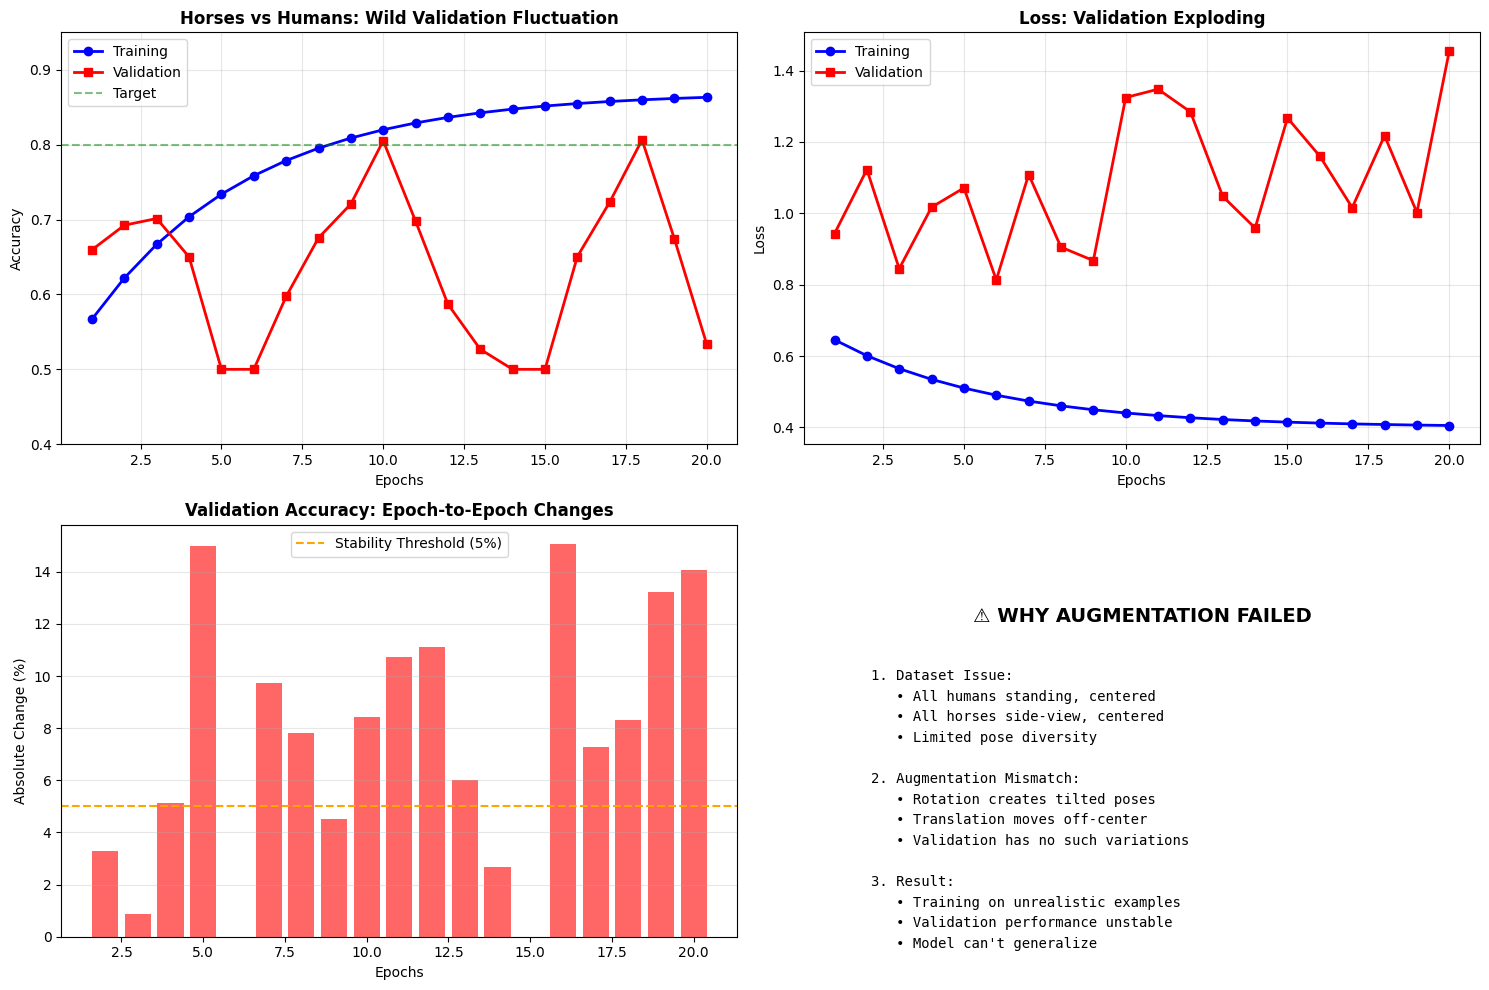


HORSES VS HUMANS: AUGMENTATION FAILURE ANALYSIS

Final Results:
  Training Accuracy:   86.3% ✓
  Validation Accuracy: 53.3% (unstable)
  Validation Loss:     1.45 (high)

Instability Metrics:
  Avg epoch-to-epoch change: 7.5%
  Max fluctuation:           15.0%
  Validation range:          50.0% - 80.6%

⚠ Clear signs of augmentation-validation mismatch!


In [11]:
def simulate_augmentation_failure():
    """
    Simulate the Horses vs Humans scenario where augmentation doesn't help
    """
    epochs = np.arange(1, 21)
    
    # Training accuracy steadily improves
    train_acc = 0.5 + 0.37 * (1 - np.exp(-epochs/5))
    
    # Validation accuracy fluctuates wildly
    np.random.seed(42)
    val_acc_base = 0.5 + 0.15 * (1 - np.exp(-epochs/5))
    val_acc = val_acc_base + 0.15 * np.sin(epochs * 0.8) + 0.05 * np.random.randn(len(epochs))
    val_acc = np.clip(val_acc, 0.5, 0.85)
    
    # Validation loss explodes
    val_loss = 0.7 + 0.3 * epochs/20 + 0.5 * np.random.rand(len(epochs))
    train_loss = 0.7 - 0.3 * (1 - np.exp(-epochs/5))
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Accuracy - Wild Fluctuation
    axes[0, 0].plot(epochs, train_acc, 'b-', linewidth=2, label='Training', marker='o')
    axes[0, 0].plot(epochs, val_acc, 'r-', linewidth=2, label='Validation', marker='s')
    axes[0, 0].axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='Target')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_title('Horses vs Humans: Wild Validation Fluctuation', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim([0.4, 0.95])
    
    # Plot 2: Loss - Explosion
    axes[0, 1].plot(epochs, train_loss, 'b-', linewidth=2, label='Training', marker='o')
    axes[0, 1].plot(epochs, val_loss, 'r-', linewidth=2, label='Validation', marker='s')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Loss: Validation Exploding', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Validation Accuracy Instability
    epoch_to_epoch_change = np.abs(np.diff(val_acc)) * 100
    axes[1, 0].bar(epochs[1:], epoch_to_epoch_change, color='red', alpha=0.6)
    axes[1, 0].axhline(y=5, color='orange', linestyle='--', label='Stability Threshold (5%)')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Absolute Change (%)')
    axes[1, 0].set_title('Validation Accuracy: Epoch-to-Epoch Changes', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Problem Visualization
    axes[1, 1].text(0.5, 0.8, '⚠ WHY AUGMENTATION FAILED', 
                    ha='center', va='top', fontsize=14, fontweight='bold',
                    transform=axes[1, 1].transAxes)
    
    problems = [
        "1. Dataset Issue:",
        "   • All humans standing, centered",
        "   • All horses side-view, centered",
        "   • Limited pose diversity",
        "",
        "2. Augmentation Mismatch:",
        "   • Rotation creates tilted poses",
        "   • Translation moves off-center",
        "   • Validation has no such variations",
        "",
        "3. Result:",
        "   • Training on unrealistic examples",
        "   • Validation performance unstable",
        "   • Model can't generalize"
    ]
    
    y_pos = 0.65
    for problem in problems:
        axes[1, 1].text(0.1, y_pos, problem, 
                       ha='left', va='top', fontsize=10,
                       transform=axes[1, 1].transAxes,
                       family='monospace')
        y_pos -= 0.05
    
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*60)
    print("HORSES VS HUMANS: AUGMENTATION FAILURE ANALYSIS")
    print("="*60)
    print(f"\nFinal Results:")
    print(f"  Training Accuracy:   {train_acc[-1]:.1%} ✓")
    print(f"  Validation Accuracy: {val_acc[-1]:.1%} (unstable)")
    print(f"  Validation Loss:     {val_loss[-1]:.2f} (high)")
    print(f"\nInstability Metrics:")
    print(f"  Avg epoch-to-epoch change: {np.mean(epoch_to_epoch_change):.1f}%")
    print(f"  Max fluctuation:           {np.max(epoch_to_epoch_change):.1f}%")
    print(f"  Validation range:          {np.min(val_acc):.1%} - {np.max(val_acc):.1%}")
    print(f"\n⚠ Clear signs of augmentation-validation mismatch!")

simulate_augmentation_failure()

# Training Cats vs Dogs with Data Augmentation

Complete Practical Implementation Guide
This guide provides a complete, runnable implementation for training a CNN on the Cats vs Dogs dataset with data augmentation to prevent overfitting.

## Part 2: Data Preparation

### Dataset Structure

The Cats vs Dogs dataset should be organized as follows:

```
cats_and_dogs_filtered/
├── train/
│   ├── cats/
│   │   ├── cat.0.jpg
│   │   ├── cat.1.jpg
│   │   └── ...
│   └── dogs/
│       ├── dog.0.jpg
│       ├── dog.1.jpg
│       └── ...
└── validation/
    ├── cats/
    │   ├── cat.2000.jpg
    │   └── ...
    └── dogs/
        ├── dog.2000.jpg
        └── ...

```


### Loading the Dataset

In [18]:
# Define base directory
BASE_DIR = '../data/cats_and_dogs_filtered'

# Define paths
train_dir = os.path.join(BASE_DIR, 'train')
validation_dir = os.path.join(BASE_DIR, 'validation')

# Training directories
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Validation directories
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

# Print dataset statistics
print(f"\nDataset Statistics:")
print(f"Training cats: {len(os.listdir(train_cats_dir))}")
print(f"Training dogs: {len(os.listdir(train_dogs_dir))}")
print(f"Validation cats: {len(os.listdir(validation_cats_dir))}")
print(f"Validation dogs: {len(os.listdir(validation_dogs_dir))}")



Dataset Statistics:
Training cats: 1000
Training dogs: 1000
Validation cats: 500
Validation dogs: 500


## Creating Datasets with TensorFlow


In [19]:
# Image parameters
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

# Create training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42
)

# Create validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False  # Don't shuffle validation data
)

# Optimize datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("\n✓ Datasets created and optimized")


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.

✓ Datasets created and optimized


## Visualizing Sample Images



Sample Training Images:


2025-10-07 12:46:23.278299: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-10-07 12:46:23.870728: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


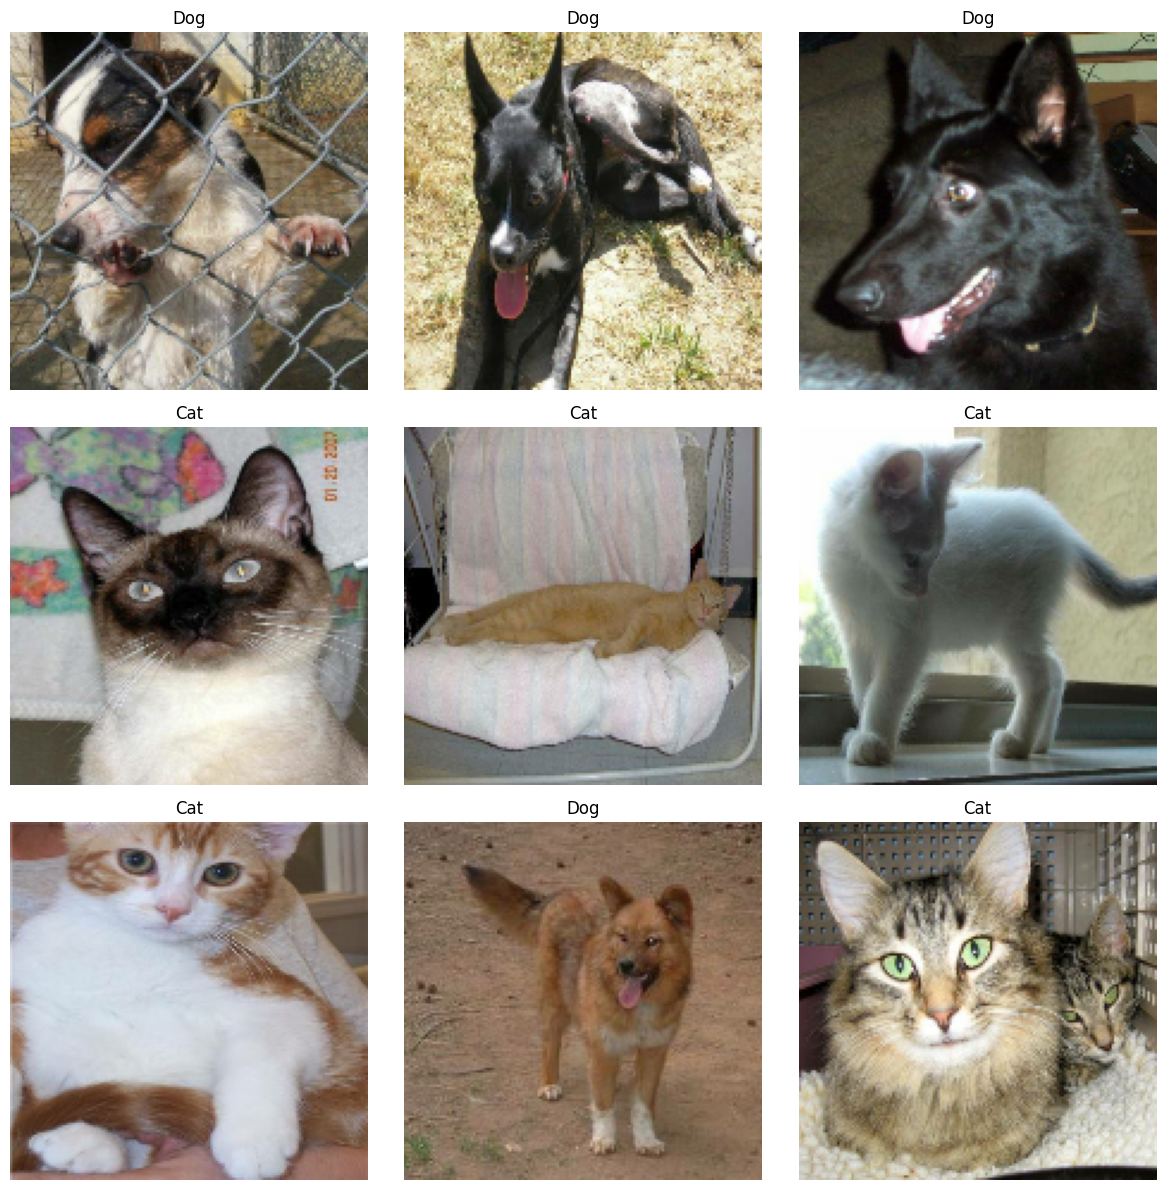

In [20]:
def visualize_dataset_samples(dataset, num_images=9):
    """
    Visualize sample images from the dataset
    """
    plt.figure(figsize=(12, 12))
    
    # Get one batch
    for images, labels in dataset.take(1):
        for i in range(min(num_images, len(images))):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            label = "Dog" if labels[i] == 1 else "Cat"
            plt.title(f"{label}")
            plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Visualize training samples
print("\nSample Training Images:")
visualize_dataset_samples(train_dataset)

## Creating the Augmentation Pipeline


In [21]:
def create_augmentation_model():
    """
    Creates a data augmentation model using Keras preprocessing layers.
    
    Returns:
        tf.keras.Sequential: Augmentation model
    """
    augmentation_model = tf.keras.Sequential([
        layers.Input(shape=(150, 150, 3)),
        
        # Randomly flip images horizontally
        layers.RandomFlip("horizontal"),
        
        # Rotate images by up to ±36 degrees (0.1 * 2π)
        layers.RandomRotation(0.1, fill_mode="nearest"),
        
        # Shift images by up to 10% in each direction
        layers.RandomTranslation(0.1, 0.1, fill_mode="nearest"),
        
        # Zoom by up to ±10%
        layers.RandomZoom(0.1, fill_mode="nearest"),
        
        # Optional: Add brightness variation
        # layers.RandomBrightness(0.2),
        
        # Optional: Add contrast variation
        # layers.RandomContrast(0.2),
        
    ], name='data_augmentation')
    
    return augmentation_model

# Create the augmentation model
data_augmentation = create_augmentation_model()

print("\n✓ Data augmentation model created")
print("\nAugmentation Layers:")
for layer in data_augmentation.layers:
    print(f"  - {layer.name}")


✓ Data augmentation model created

Augmentation Layers:
  - random_flip_5
  - random_rotation_5
  - random_translation_5
  - random_zoom_5


## Visualizing Augmentation Effects



Visualizing Augmentation Effects:


2025-10-07 12:47:32.489547: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


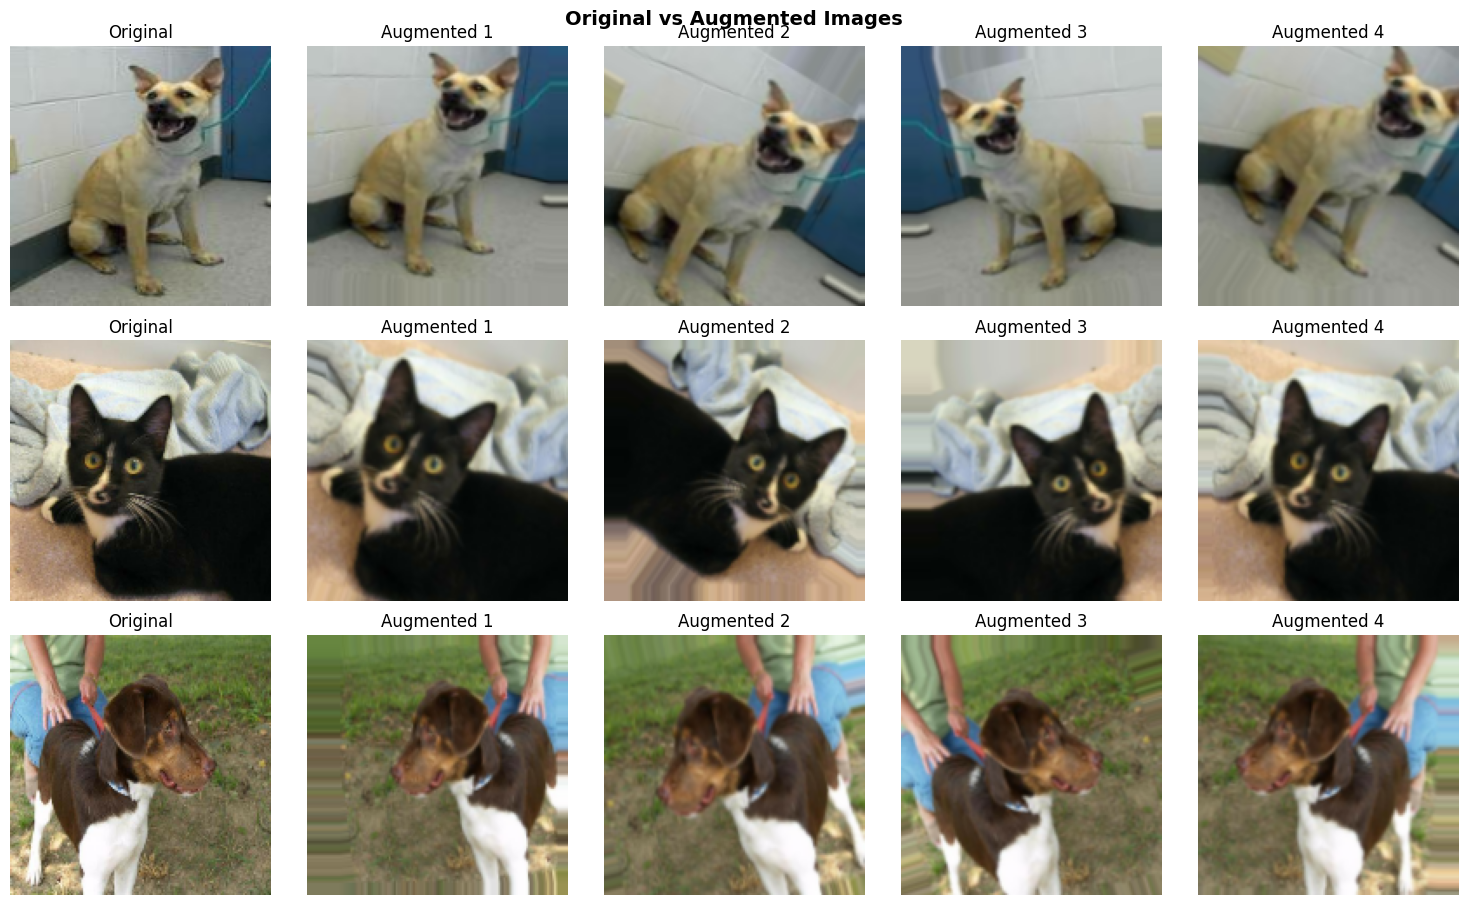

In [22]:
def visualize_augmentations(dataset, augmentation_model, num_examples=3):
    """
    Show original images alongside their augmented versions
    """
    # Get one batch
    for images, labels in dataset.take(1):
        fig, axes = plt.subplots(num_examples, 5, figsize=(15, num_examples * 3))
        
        for i in range(num_examples):
            # Original image
            axes[i, 0].imshow(images[i].numpy().astype("uint8"))
            axes[i, 0].set_title("Original")
            axes[i, 0].axis("off")
            
            # Generate 4 augmented versions
            for j in range(1, 5):
                augmented = augmentation_model(tf.expand_dims(images[i], 0), training=True)
                axes[i, j].imshow(tf.squeeze(augmented).numpy().astype("uint8"))
                axes[i, j].set_title(f"Augmented {j}")
                axes[i, j].axis("off")
        
        plt.tight_layout()
        plt.suptitle("Original vs Augmented Images", y=1.001, fontsize=14, fontweight='bold')
        plt.show()
        break

# Visualize augmentation effects
print("\nVisualizing Augmentation Effects:")
visualize_augmentations(train_dataset, data_augmentation)


## Building the CNN Model

### Model WITHOUT Augmentation (Baseline)


In [23]:
def create_baseline_model():
    """
    Creates a baseline CNN without data augmentation.
    
    Returns:
        Compiled Keras model
    """
    model = tf.keras.Sequential([
        layers.Input(shape=(150, 150, 3)),
        
        # Rescaling layer
        layers.Rescaling(1./255),
        
        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Convolutional Block 4
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name='baseline_model')
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create baseline model
baseline_model = create_baseline_model()

print("\n✓ Baseline Model (WITHOUT Augmentation):")
print(f"Total Parameters: {baseline_model.count_params():,}")



✓ Baseline Model (WITHOUT Augmentation):
Total Parameters: 3,453,121


### Model WITH Augmentation


In [24]:
def create_augmented_model():
    """
    Creates a CNN with integrated data augmentation.
    
    Returns:
        Compiled Keras model
    """
    # Get augmentation layers
    augmentation_layers = create_augmentation_model()
    
    model = tf.keras.Sequential([
        layers.Input(shape=(150, 150, 3)),
        
        # Data augmentation (only active during training)
        augmentation_layers,
        
        # Rescaling layer (always active)
        layers.Rescaling(1./255),
        
        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Convolutional Block 4
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ], name='augmented_model')
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create augmented model
augmented_model = create_augmented_model()

print("\n✓ Augmented Model (WITH Augmentation):")
print(f"Total Parameters: {augmented_model.count_params():,}")

# Display model summary
print("\nModel Architecture:")
augmented_model.summary()


✓ Augmented Model (WITH Augmentation):
Total Parameters: 3,453,121

Model Architecture:


Model: "augmented_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

## Part 8: Training the Models

### Training Baseline Model (WITHOUT Augmentation)

In [27]:
print("\n" + "="*70)
print("TRAINING BASELINE MODEL (WITHOUT AUGMENTATION)")
print("="*70)

# Train for 20 epochs
EPOCHS_BASELINE = 20

history_baseline = baseline_model.fit(
    train_dataset,
    epochs=EPOCHS_BASELINE,
    validation_data=validation_dataset,
    verbose=1
)

print("\n✓ Baseline training complete!")
print(f"Final Training Accuracy: {history_baseline.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_baseline.history['val_accuracy'][-1]:.4f}")




TRAINING BASELINE MODEL (WITHOUT AUGMENTATION)
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 476ms/step - accuracy: 0.5210 - loss: 0.6903 - val_accuracy: 0.5000 - val_loss: 0.7126
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 473ms/step - accuracy: 0.5695 - loss: 0.6767 - val_accuracy: 0.5020 - val_loss: 0.7274
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 468ms/step - accuracy: 0.6035 - loss: 0.6602 - val_accuracy: 0.5120 - val_loss: 0.7238
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 465ms/step - accuracy: 0.6330 - loss: 0.6404 - val_accuracy: 0.5460 - val_loss: 0.7038
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 468ms/step - accuracy: 0.6690 - loss: 0.6174 - val_accuracy: 0.5860 - val_loss: 0.6700
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 473ms/step - accuracy: 0.6905 - loss: 0.5921 - val_accuracy: 0.6390 - val_loss: 0.6330
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 453ms/step - accuracy: 0.7165 - loss: 0.5677 - val_accuracy: 0.6790 - val_loss: 0.6140
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 429ms/s

### Training Augmented Model (WITH Augmentation)

In [26]:
print("\n" + "="*70)
print("TRAINING AUGMENTED MODEL (WITH AUGMENTATION)")
print("="*70)

# Train for more epochs since augmentation requires longer training
EPOCHS_AUGMENTED = 20

# Create early stopping callback
class EarlyStoppingCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') >= 0.85 and logs.get('val_accuracy') >= 0.85:
            print(f"\n✓ Reached 85% accuracy on both training and validation!")
            print("  Stopping training early...")
            self.model.stop_training = True

history_augmented = augmented_model.fit(
    train_dataset,
    epochs=EPOCHS_AUGMENTED,
    validation_data=validation_dataset,
    callbacks=[EarlyStoppingCallback()],
    verbose=1
)

print("\n✓ Augmented training complete!")
print(f"Final Training Accuracy: {history_augmented.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_augmented.history['val_accuracy'][-1]:.4f}")



TRAINING AUGMENTED MODEL (WITH AUGMENTATION)
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.5175 - loss: 0.6916 - val_accuracy: 0.5010 - val_loss: 0.6930
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 498ms/step - accuracy: 0.5350 - loss: 0.6881 - val_accuracy: 0.5040 - val_loss: 0.6949
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 500ms/step - accuracy: 0.5740 - loss: 0.6797 - val_accuracy: 0.5060 - val_loss: 0.7041
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 490ms/step - accuracy: 0.5935 - loss: 0.6691 - val_accuracy: 0.5350 - val_loss: 0.7030
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 498ms/step - accuracy: 0.6050 - loss: 0.6599 - val_accuracy: 0.5650 - val_loss: 0.6874
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 502ms/step - accuracy: 0.6315 - loss: 0.6469 - val_accuracy: 0.5670 - val_loss: 0.6962
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 500ms/step - accuracy: 0.6385 - loss: 0.6385 - val_accuracy: 0.6030 - val_loss: 0.6681
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 497ms/ste

## Analyzing and Visualizing Results

### Plotting Training History


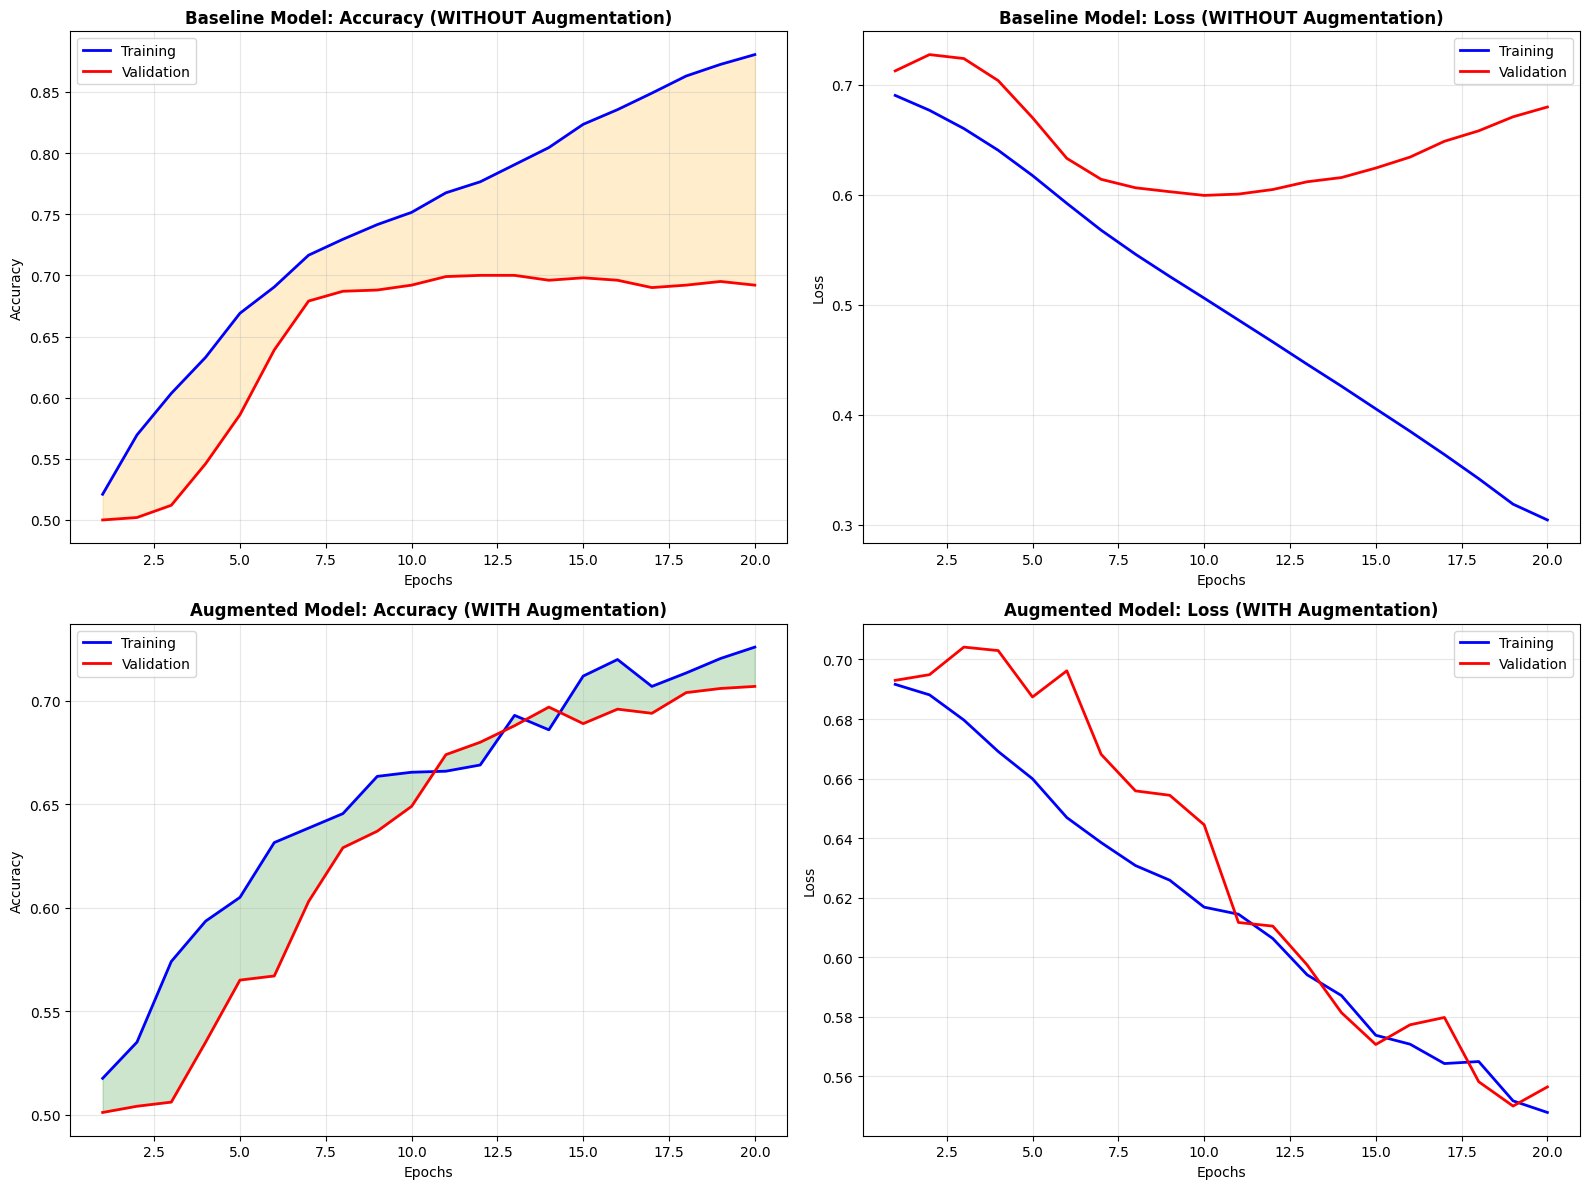

In [28]:
def plot_training_comparison(history_baseline, history_augmented):
    """
    Compare training results between baseline and augmented models
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Get data
    epochs_baseline = range(1, len(history_baseline.history['accuracy']) + 1)
    epochs_augmented = range(1, len(history_augmented.history['accuracy']) + 1)
    
    # Plot 1: Baseline Accuracy
    axes[0, 0].plot(epochs_baseline, history_baseline.history['accuracy'], 
                    'b-', linewidth=2, label='Training')
    axes[0, 0].plot(epochs_baseline, history_baseline.history['val_accuracy'], 
                    'r-', linewidth=2, label='Validation')
    axes[0, 0].fill_between(epochs_baseline, 
                            history_baseline.history['accuracy'],
                            history_baseline.history['val_accuracy'],
                            alpha=0.2, color='orange')
    axes[0, 0].set_title('Baseline Model: Accuracy (WITHOUT Augmentation)', 
                         fontweight='bold', fontsize=12)
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Baseline Loss
    axes[0, 1].plot(epochs_baseline, history_baseline.history['loss'], 
                    'b-', linewidth=2, label='Training')
    axes[0, 1].plot(epochs_baseline, history_baseline.history['val_loss'], 
                    'r-', linewidth=2, label='Validation')
    axes[0, 1].set_title('Baseline Model: Loss (WITHOUT Augmentation)', 
                         fontweight='bold', fontsize=12)
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Augmented Accuracy
    axes[1, 0].plot(epochs_augmented, history_augmented.history['accuracy'], 
                    'b-', linewidth=2, label='Training')
    axes[1, 0].plot(epochs_augmented, history_augmented.history['val_accuracy'], 
                    'r-', linewidth=2, label='Validation')
    axes[1, 0].fill_between(epochs_augmented,
                            history_augmented.history['accuracy'],
                            history_augmented.history['val_accuracy'],
                            alpha=0.2, color='green')
    axes[1, 0].set_title('Augmented Model: Accuracy (WITH Augmentation)', 
                         fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Augmented Loss
    axes[1, 1].plot(epochs_augmented, history_augmented.history['loss'], 
                    'b-', linewidth=2, label='Training')
    axes[1, 1].plot(epochs_augmented, history_augmented.history['val_loss'], 
                    'r-', linewidth=2, label='Validation')
    axes[1, 1].set_title('Augmented Model: Loss (WITH Augmentation)', 
                         fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot comparison
plot_training_comparison(history_baseline, history_augmented)


### Overfitting Gap Analysis


In [29]:
def analyze_overfitting_gap(history_baseline, history_augmented):
    """
    Calculate and display overfitting gap metrics
    """
    # Final epoch metrics
    baseline_train_acc = history_baseline.history['accuracy'][-1]
    baseline_val_acc = history_baseline.history['val_accuracy'][-1]
    baseline_gap = (baseline_train_acc - baseline_val_acc) * 100
    
    augmented_train_acc = history_augmented.history['accuracy'][-1]
    augmented_val_acc = history_augmented.history['val_accuracy'][-1]
    augmented_gap = (augmented_train_acc - augmented_val_acc) * 100
    
    print("\n" + "="*70)
    print("OVERFITTING GAP ANALYSIS")
    print("="*70)
    
    print("\nBaseline Model (WITHOUT Augmentation):")
    print(f"  Training Accuracy:   {baseline_train_acc:.2%}")
    print(f"  Validation Accuracy: {baseline_val_acc:.2%}")
    print(f"  Overfitting Gap:     {baseline_gap:.2f}%")
    
    print("\nAugmented Model (WITH Augmentation):")
    print(f"  Training Accuracy:   {augmented_train_acc:.2%}")
    print(f"  Validation Accuracy: {augmented_val_acc:.2%}")
    print(f"  Overfitting Gap:     {augmented_gap:.2f}%")
    
    print("\n" + "-"*70)
    print("IMPROVEMENT:")
    print(f"  Gap Reduction:       {baseline_gap - augmented_gap:.2f}%")
    print(f"  Validation Improvement: {(augmented_val_acc - baseline_val_acc)*100:.2f}%")
    
    if augmented_gap < baseline_gap:
        print("\n✓ Augmentation successfully reduced overfitting!")
    else:
        print("\n⚠ Augmentation did not reduce overfitting as expected.")
    
    print("="*70)

# Analyze overfitting
analyze_overfitting_gap(history_baseline, history_augmented)



OVERFITTING GAP ANALYSIS

Baseline Model (WITHOUT Augmentation):
  Training Accuracy:   88.05%
  Validation Accuracy: 69.20%
  Overfitting Gap:     18.85%

Augmented Model (WITH Augmentation):
  Training Accuracy:   72.60%
  Validation Accuracy: 70.70%
  Overfitting Gap:     1.90%

----------------------------------------------------------------------
IMPROVEMENT:
  Gap Reduction:       16.95%
  Validation Improvement: 1.50%

✓ Augmentation successfully reduced overfitting!


### Decision Framework: When to Use Augmentation

In [12]:
def augmentation_decision_framework():
    """
    Print a decision framework for when to use augmentation
    """
    print("\n" + "="*70)
    print("AUGMENTATION DECISION FRAMEWORK")
    print("="*70)
    
    framework = {
        "✓ USE Augmentation When:": [
            "Dataset has natural diversity in poses/angles",
            "Validation set represents similar variety",
            "Objects can appear in different orientations",
            "Real-world usage has natural variations",
            "Limited training data (< 10,000 images)",
            "Training/validation gap is large (overfitting)"
        ],
        "✗ AVOID Augmentation When:": [
            "Dataset has artificial consistency (all centered)",
            "Validation set lacks diversity",
            "Orientation matters (text, signs, medical scans)",
            "Augmentation creates unrealistic examples",
            "Background patterns are being learned",
            "Validation accuracy fluctuates wildly"
        ],
        "⚠ Warning Signs:": [
            "Validation accuracy varies >10% between epochs",
            "Validation loss increases over time",
            "Training accuracy >> validation accuracy",
            "Model performance degrades with augmentation"
        ],
        "💡 Alternatives to Consider:": [
            "Collect more diverse training data",
            "Redesign validation set to match real usage",
            "Use transfer learning (Week 3 topic)",
            "Apply gentler augmentation parameters",
            "Use only specific augmentations that make sense"
        ]
    }
    
    for category, items in framework.items():
        print(f"\n{category}")
        print("-" * 70)
        for item in items:
            print(f"  • {item}")
    
    print("\n" + "="*70)

augmentation_decision_framework()


AUGMENTATION DECISION FRAMEWORK

✓ USE Augmentation When:
----------------------------------------------------------------------
  • Dataset has natural diversity in poses/angles
  • Validation set represents similar variety
  • Objects can appear in different orientations
  • Real-world usage has natural variations
  • Limited training data (< 10,000 images)
  • Training/validation gap is large (overfitting)

✗ AVOID Augmentation When:
----------------------------------------------------------------------
  • Dataset has artificial consistency (all centered)
  • Validation set lacks diversity
  • Orientation matters (text, signs, medical scans)
  • Augmentation creates unrealistic examples
  • Background patterns are being learned
  • Validation accuracy fluctuates wildly

⚠ Warning Signs:
----------------------------------------------------------------------
  • Validation accuracy varies >10% between epochs
  • Validation loss increases over time
  • Training accuracy >> validation

---
## Practical Guidelines and Best Practices

In [13]:
def print_best_practices():
    """
    Print comprehensive best practices for augmentation
    """
    print("\n" + "="*70)
    print("AUGMENTATION BEST PRACTICES")
    print("="*70)
    
    practices = {
        "1. START CONSERVATIVE": [
            "Begin with mild augmentations:",
            "  - RandomFlip('horizontal')",
            "  - RandomRotation(0.1)  # ±36 degrees",
            "  - RandomZoom(0.1)      # ±10%",
            "Gradually increase if needed"
        ],
        "2. MONITOR VALIDATION METRICS": [
            "Watch for:",
            "  - Stable validation accuracy",
            "  - Decreasing validation loss",
            "  - Small train/val gap (<10%)",
            "  - Smooth training curves"
        ],
        "3. PROBLEM-SPECIFIC CHOICES": [
            "Natural photos (cats, dogs):",
            "  → Use: Flip, Rotation, Zoom, Brightness",
            "",
            "Centered objects (faces):",
            "  → Use: Small Translation, Zoom, Brightness",
            "  → Avoid: Large Rotation, Flip",
            "",
            "Text/Documents:",
            "  → Use: Small Rotation (<10°), Brightness",
            "  → Avoid: Flip, Large Rotation",
            "",
            "Medical Images:",
            "  → Use: Carefully! Some transforms change diagnosis",
            "  → Consult domain experts"
        ],
        "4. COMMON PARAMETER RANGES": [
            "Conservative:  RandomRotation(0.05), RandomZoom(0.1)",
            "Moderate:      RandomRotation(0.2),  RandomZoom(0.2)",
            "Aggressive:    RandomRotation(0.3),  RandomZoom(0.3)",
            "",
            "Start conservative, increase only if:",
            "  - Still overfitting after training",
            "  - Validation accuracy not improving"
        ],
        "5. TRAINING TIME CONSIDERATIONS": [
            "Augmentation increases training time:",
            "  - Each epoch takes longer",
            "  - May need more epochs (20 → 50-100)",
            "  - Use callbacks to stop early",
            "",
            "Optimization:",
            "  - Use GPU acceleration",
            "  - Add augmentation as model layers (not in dataset)",
            "  - Use prefetch() and cache() in data pipeline"
        ],
        "6. DEBUGGING FAILED AUGMENTATION": [
            "If augmentation doesn't help:",
            "",
            "Step 1: Visualize augmented images",
            "  → Are they realistic?",
            "",
            "Step 2: Compare train and validation images",
            "  → Do they have similar variety?",
            "",
            "Step 3: Check validation metrics",
            "  → Is accuracy fluctuating wildly?",
            "",
            "Step 4: Consider alternatives",
            "  → Transfer learning, more data, redesign validation"
        ]
    }
    
    for section, points in practices.items():
        print(f"\n{section}")
        print("-" * 70)
        for point in points:
            print(f"  {point}")
    
    print("\n" + "="*70)

print_best_practices()


AUGMENTATION BEST PRACTICES

1. START CONSERVATIVE
----------------------------------------------------------------------
  Begin with mild augmentations:
    - RandomFlip('horizontal')
    - RandomRotation(0.1)  # ±36 degrees
    - RandomZoom(0.1)      # ±10%
  Gradually increase if needed

2. MONITOR VALIDATION METRICS
----------------------------------------------------------------------
  Watch for:
    - Stable validation accuracy
    - Decreasing validation loss
    - Small train/val gap (<10%)
    - Smooth training curves

3. PROBLEM-SPECIFIC CHOICES
----------------------------------------------------------------------
  Natural photos (cats, dogs):
    → Use: Flip, Rotation, Zoom, Brightness
  
  Centered objects (faces):
    → Use: Small Translation, Zoom, Brightness
    → Avoid: Large Rotation, Flip
  
  Text/Documents:
    → Use: Small Rotation (<10°), Brightness
    → Avoid: Flip, Large Rotation
  
  Medical Images:
    → Use: Carefully! Some transforms change diagnosis
 

---
## Augmentation Parameter Experimentation Tool

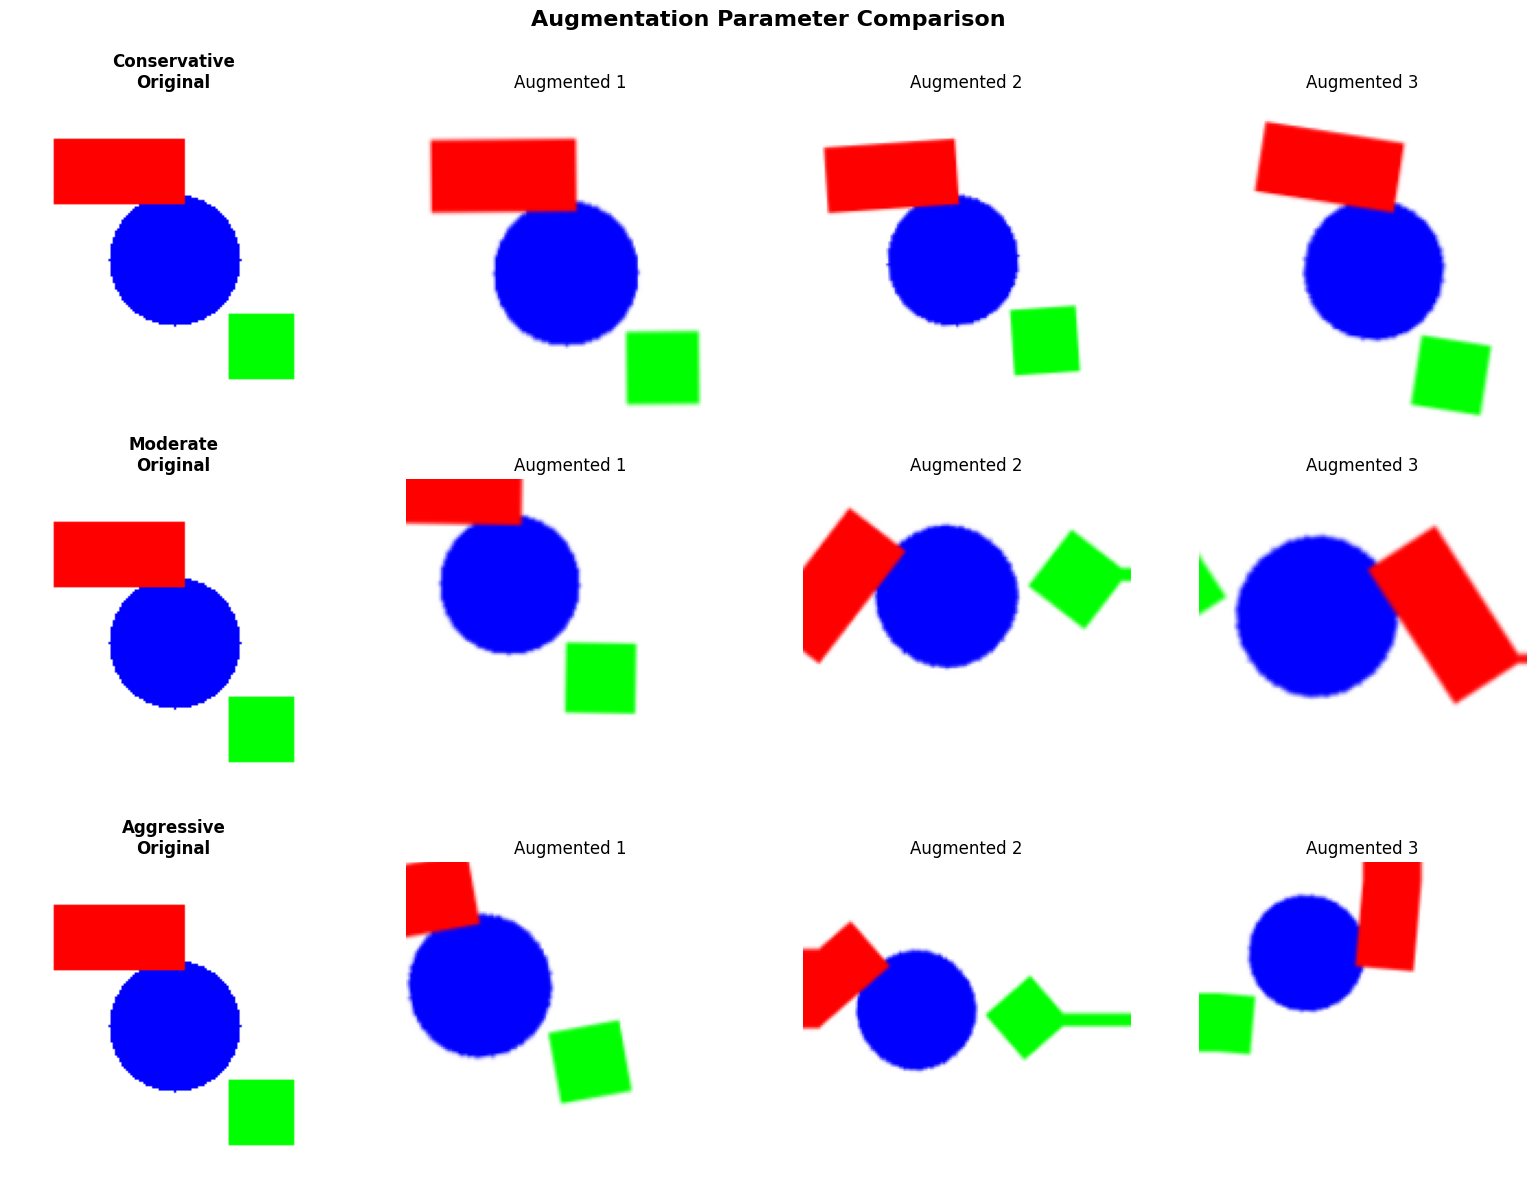


PARAMETER CONFIGURATIONS

Conservative:
  flip        : horizontal
  rotation    : 0.05 (±18°)
  translation : 0.05 (±5%)
  zoom        : 0.10 (±10%)

Moderate:
  flip        : horizontal
  rotation    : 0.20 (±72°)
  translation : 0.20 (±20%)
  zoom        : 0.20 (±20%)

Aggressive:
  flip        : horizontal_and_vertical
  rotation    : 0.30 (±108°)
  translation : 0.30 (±30%)
  zoom        : 0.30 (±30%)


In [14]:
def experiment_with_parameters(image_size=(150, 150)):
    """
    Interactive tool to experiment with different augmentation parameters
    """
    # Create sample image
    sample_image = create_sample_image(image_size)
    
    # Different augmentation configurations
    configs = {
        "Conservative": {
            "flip": "horizontal",
            "rotation": 0.05,
            "translation": 0.05,
            "zoom": 0.1
        },
        "Moderate": {
            "flip": "horizontal",
            "rotation": 0.2,
            "translation": 0.2,
            "zoom": 0.2
        },
        "Aggressive": {
            "flip": "horizontal_and_vertical",
            "rotation": 0.3,
            "translation": 0.3,
            "zoom": 0.3
        }
    }
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    for row, (config_name, params) in enumerate(configs.items()):
        # Create augmentation model with these parameters
        aug_model = keras.Sequential([
            layers.Input(shape=(*image_size, 3)),
            layers.RandomFlip(params["flip"]),
            layers.RandomRotation(params["rotation"], fill_mode="nearest"),
            layers.RandomTranslation(params["translation"], params["translation"], fill_mode="nearest"),
            layers.RandomZoom(params["zoom"], fill_mode="nearest")
        ])
        
        # Original image
        axes[row, 0].imshow(sample_image.astype('uint8'))
        axes[row, 0].set_title(f'{config_name}\nOriginal', fontweight='bold')
        axes[row, 0].axis('off')
        
        # Generate 3 augmented versions
        for col in range(1, 4):
            augmented = aug_model(tf.expand_dims(sample_image, 0), training=True)
            augmented = tf.squeeze(augmented).numpy()
            axes[row, col].imshow(augmented.astype('uint8'))
            axes[row, col].set_title(f'Augmented {col}')
            axes[row, col].axis('off')
    
    plt.suptitle('Augmentation Parameter Comparison', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # Print parameters
    print("\n" + "="*70)
    print("PARAMETER CONFIGURATIONS")
    print("="*70)
    for config_name, params in configs.items():
        print(f"\n{config_name}:")
        for key, value in params.items():
            if key == "rotation":
                degrees = value * 360
                print(f"  {key:12s}: {value:.2f} (±{degrees:.0f}°)")
            elif key == "flip":
                print(f"  {key:12s}: {value}")
            else:
                print(f"  {key:12s}: {value:.2f} (±{value*100:.0f}%)")

experiment_with_parameters()

---
## Quick Reference: Augmentation Layers Cheat Sheet

In [15]:
def print_augmentation_cheat_sheet():
    """
    Print a comprehensive cheat sheet of augmentation layers
    """
    print("\n" + "="*80)
    print("KERAS AUGMENTATION LAYERS CHEAT SHEET")
    print("="*80)
    
    layers_info = [
        {
            "Layer": "RandomFlip",
            "Code": "layers.RandomFlip('horizontal')",
            "Parameters": "mode: 'horizontal', 'vertical', 'horizontal_and_vertical'",
            "Use Case": "Objects that look similar when flipped"
        },
        {
            "Layer": "RandomRotation",
            "Code": "layers.RandomRotation(0.2)",
            "Parameters": "factor: fraction of 2π (0.2 = ±72°)",
            "Use Case": "Objects at different angles"
        },
        {
            "Layer": "RandomTranslation",
            "Code": "layers.RandomTranslation(0.2, 0.2)",
            "Parameters": "height_factor, width_factor: fraction of image size",
            "Use Case": "Off-center objects"
        },
        {
            "Layer": "RandomZoom",
            "Code": "layers.RandomZoom(0.2)",
            "Parameters": "height_factor: zoom amount (0.2 = ±20%)",
            "Use Case": "Objects at different scales"
        },
        {
            "Layer": "RandomBrightness",
            "Code": "layers.RandomBrightness(0.2)",
            "Parameters": "factor: brightness range (0.2 = ±20%)",
            "Use Case": "Different lighting conditions"
        },
        {
            "Layer": "RandomContrast",
            "Code": "layers.RandomContrast(0.2)",
            "Parameters": "factor: contrast range (0.2 = ±20%)",
            "Use Case": "Varying image quality"
        },
        {
            "Layer": "Rescaling",
            "Code": "layers.Rescaling(1./255)",
            "Parameters": "scale: multiplier for pixel values",
            "Use Case": "Normalize pixels (always use!)"
        }
    ]
    
    for info in layers_info:
        print(f"\n📌 {info['Layer']}")
        print(f"   Code:       {info['Code']}")
        print(f"   Parameters: {info['Parameters']}")
        print(f"   Use Case:   {info['Use Case']}")
    
    print("\n" + "-"*80)
    print("\n💡 COMPLETE EXAMPLE:")
    print("""
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2, fill_mode="nearest"),
    layers.RandomTranslation(0.2, 0.2, fill_mode="nearest"),
    layers.RandomZoom(0.2, fill_mode="nearest"),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2)
])

model = tf.keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,      # Augmentation first
    layers.Rescaling(1./255),  # Then rescaling
    # ... rest of your CNN layers ...
])
    """)
    print("="*80)

print_augmentation_cheat_sheet()


KERAS AUGMENTATION LAYERS CHEAT SHEET

📌 RandomFlip
   Code:       layers.RandomFlip('horizontal')
   Parameters: mode: 'horizontal', 'vertical', 'horizontal_and_vertical'
   Use Case:   Objects that look similar when flipped

📌 RandomRotation
   Code:       layers.RandomRotation(0.2)
   Parameters: factor: fraction of 2π (0.2 = ±72°)
   Use Case:   Objects at different angles

📌 RandomTranslation
   Code:       layers.RandomTranslation(0.2, 0.2)
   Parameters: height_factor, width_factor: fraction of image size
   Use Case:   Off-center objects

📌 RandomZoom
   Code:       layers.RandomZoom(0.2)
   Parameters: height_factor: zoom amount (0.2 = ±20%)
   Use Case:   Objects at different scales

📌 RandomBrightness
   Code:       layers.RandomBrightness(0.2)
   Parameters: factor: brightness range (0.2 = ±20%)
   Use Case:   Different lighting conditions

📌 RandomContrast
   Code:       layers.RandomContrast(0.2)
   Parameters: factor: contrast range (0.2 = ±20%)
   Use Case:   Varying i

---
## Summary and Key Takeaways

In [16]:
def print_week2_summary():
    """
    Print comprehensive summary of Week 2 concepts
    """
    print("\n" + "="*80)
    print("WEEK 2 SUMMARY: IMAGE AUGMENTATION AND OVERFITTING")
    print("="*80)
    
    summary = {
        "🎯 Core Concepts": [
            "Overfitting: Model memorizes training data, fails on new data",
            "Augmentation: Creating variations in-memory during training",
            "Generalization: Goal is good performance on unseen data",
            "Dataset quality matters more than quantity"
        ],
        "✓ What Works": [
            "Augmentation on datasets with natural diversity (cats vs dogs)",
            "Conservative parameters that create realistic variations",
            "Matching augmentation to real-world usage scenarios",
            "Monitoring validation metrics for stability"
        ],
        "✗ What Doesn't Work": [
            "Augmentation on artificially consistent datasets (horses vs humans)",
            "Creating unrealistic variations that don't match validation",
            "Aggressive augmentation without checking validation stability",
            "Using augmentation as a substitute for good data"
        ],
        "🔑 Key Metrics": [
            "Training/Validation Gap: Should be <10% for good generalization",
            "Validation Stability: Should not fluctuate >5% between epochs",
            "MSE between curves: Should be <20% for assignment passing",
            "Both accuracies: Target 80%+ for real-world applications"
        ],
        "💻 Implementation Steps": [
            "1. Create augmentation model with Sequential layers",
            "2. Add augmentation before rescaling in main model",
            "3. Use fill_mode='nearest' for transformations",
            "4. Set up EarlyStoppingCallback for efficiency",
            "5. Monitor both training and validation metrics",
            "6. Adjust parameters based on results"
        ],
        "⚠️ Warning Signs": [
            "Wild validation accuracy fluctuation (>10% per epoch)",
            "Validation loss increasing over time",
            "Large persistent gap between train/val accuracy",
            "Training improves but validation doesn't"
        ],
        "🚀 Next Steps": [
            "Week 3: Transfer Learning (when augmentation isn't enough)",
            "Practice: Experiment with different augmentation parameters",
            "Analyze: Compare your datasets before applying augmentation",
            "Understand: When to use alternatives to augmentation"
        ]
    }
    
    for section, points in summary.items():
        print(f"\n{section}")
        print("-" * 80)
        for point in points:
            print(f"  • {point}")
    
    print("\n" + "="*80)
    print("\n🎓 YOU'VE COMPLETED WEEK 2!")
    print("\nYou now understand:")
    print("  ✓ What overfitting is and how to recognize it")
    print("  ✓ How to implement image augmentation in TensorFlow")
    print("  ✓ When augmentation helps and when it doesn't")
    print("  ✓ How to monitor and interpret training metrics")
    print("\nKeep practicing and experimenting! 🚀")
    print("="*80)

print_week2_summary()


WEEK 2 SUMMARY: IMAGE AUGMENTATION AND OVERFITTING

🎯 Core Concepts
--------------------------------------------------------------------------------
  • Overfitting: Model memorizes training data, fails on new data
  • Augmentation: Creating variations in-memory during training
  • Generalization: Goal is good performance on unseen data
  • Dataset quality matters more than quantity

✓ What Works
--------------------------------------------------------------------------------
  • Augmentation on datasets with natural diversity (cats vs dogs)
  • Conservative parameters that create realistic variations
  • Matching augmentation to real-world usage scenarios
  • Monitoring validation metrics for stability

✗ What Doesn't Work
--------------------------------------------------------------------------------
  • Augmentation on artificially consistent datasets (horses vs humans)
  • Creating unrealistic variations that don't match validation
  • Aggressive augmentation without checking val

---
## Additional Resources and References

### Official Documentation
- [Keras Preprocessing Layers](https://keras.io/api/layers/preprocessing_layers/)
- [TensorFlow Data Augmentation Guide](https://www.tensorflow.org/tutorials/images/data_augmentation)
- [Keras Sequential API](https://keras.io/api/models/sequential/)

### Further Reading
- Image augmentation research papers
- AutoAugment and RandAugment techniques
- Transfer learning as an alternative (Week 3)

### Practice Datasets
- Cats vs Dogs: [Kaggle Dataset](https://www.kaggle.com/c/dogs-vs-cats)
- Horses vs Humans: Available in course materials
- CIFAR-10, MNIST: Built into TensorFlow

---
## End of Week 2 Reference Notebook

**Remember:**
- Augmentation is powerful but not magic
- Always visualize your augmented images
- Monitor validation metrics carefully
- Start conservative, increase gradually
- Know when to try alternatives (transfer learning)

**Good luck with your deep learning journey! 🎉**